In [23]:
# セル 1: 必要なライブラリのインポート (変更なし)
import glob
import os
import random

import cupy as cp  # Cupyを使用する場合
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.model_selection import train_test_split

# from tensorflow.keras.applications import VGG16 # 今回は直接使わない
from tensorflow.keras.preprocessing.image import img_to_array, load_img


In [24]:
# 再現性のための乱数シード設定
SEED = 42

# Python標準のrandomモジュールのシード設定

random.seed(SEED)

# NumPyのシード設定
np.random.seed(SEED)

# TensorFlowのシード設定
tf.random.set_seed(SEED)

# TensorFlowの決定的動作を有効化（可能な場合）
# 注: 一部の演算では完全な決定性が保証されない場合があります
try:
    tf.config.experimental.enable_op_determinism()
except AttributeError:
    # TensorFlow 2.9未満では利用できない
    pass

# 環境変数でPythonハッシュのシードを固定
os.environ["PYTHONHASHSEED"] = str(SEED)

# CuPyのシード設定（GPU使用時）
try:
    cp.random.seed(SEED)
except:
    pass

# セル 2: 設定値
# IMG_BASE_PATH = "20250425_data/Material_d_Gray/"  # 旧パス（ノートブックディレクトリから見ると不正確）
# CSV_BASE_PATH = "20250425_data/TorqData/"  # 旧パス（ノートブックディレクトリから見ると不正確）
IMG_BASE_PATH = "../20250425_data/Material_d_Gray/"  # ノートブックは notebook/ 配下にあるため親ディレクトリを指定
CSV_BASE_PATH = "../20250425_data/TorqData/"  # ノートブックは notebook/ 配下にあるため親ディレクトリを指定
IMG_HEIGHT = 224
IMG_WIDTH = 224
CHANNELS = 1  # 元画像のチャネル数 (グレースケール)
# MODEL_INPUT_CHANNELS は不要になるか、1 に設定 (モデル定義に合わせる)
BATCH_SIZE = 128  # 小さくした方が良いかもしれない (32 or 64)
EPOCHS = 100
LEARNING_RATE = (
    1e-4  # スクラッチからの学習なので、少し大きめでも良いかもしれない (1e-3)
)
TEST_SPLIT_RATIO = 0.1
VALID_SPLIT_RATIO = 0.1

# CUDAデバイスの設定 ... (変更なし)
print("利用可能なGPUデバイス (Cupy):")
try:
    for i in range(cp.cuda.runtime.getDeviceCount()):
        print(f"GPU {i}: {cp.cuda.runtime.getDeviceProperties(i)['name']}")
    if cp.cuda.runtime.getDeviceCount() > 0:
        cp.cuda.Device(0).use()
        print(f"\n選択されたCupy GPU: {cp.cuda.runtime.getDeviceProperties(0)['name']}")
    else:
        print("\nCupyが利用できるGPUが見つかりませんでした。")
except cp.cuda.runtime.CUDARuntimeError as e:
    print(f"Cupy CUDAエラー: {e}")

print("\n利用可能なGPUデバイス (TensorFlow):")
gpus = tf.config.list_physical_devices("GPU")
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print(f"{len(gpus)} 個のGPUがTensorFlowで利用可能です。")
    except RuntimeError as e:
        print(e)
else:
    print("TensorFlowで利用可能なGPUが見つかりませんでした。CPUを使用します。")


利用可能なGPUデバイス (Cupy):
GPU 0: b'NVIDIA RTX 6000 Ada Generation'
GPU 1: b'NVIDIA T600'

選択されたCupy GPU: b'NVIDIA RTX 6000 Ada Generation'

利用可能なGPUデバイス (TensorFlow):
2 個のGPUがTensorFlowで利用可能です。


In [25]:
# セル 3: CSVファイルから目的変数を抽出するヘルパー関数 (変更なし)
def get_target_value(csv_filepath):
    try:
        df = pd.read_csv(csv_filepath)
        target_df = df.head(30)
        if len(target_df) < 30:
            # print(f"警告: {csv_filepath} の行数が30未満です ({len(target_df)}行)。利用可能な行で計算します。")
            if len(target_df) == 0:
                # print(f"エラー: {csv_filepath} に有効なデータがありません。")
                return np.nan
        target_mean = target_df["T"].mean()
        return target_mean
    except Exception:
        # print(f"エラー: {csv_filepath} の処理中にエラーが発生しました: {e}")
        return np.nan


In [26]:
# セル 4: データ読み込みと準備 (画像パスと目的変数)
image_files = sorted(glob.glob(os.path.join(IMG_BASE_PATH, "SingleI_*.bmp")))
all_image_paths = []
all_targets = []

for img_path in image_files:
    basename = os.path.basename(img_path)
    try:
        parts_str = basename.replace("SingleI_", "").replace(".bmp", "")
        parts = parts_str.split("_")
        if len(parts) == 2:
            csv_filename = f"Data_{parts[0]}_{parts[1]}.csv"
            csv_filepath = os.path.join(CSV_BASE_PATH, csv_filename)
            if os.path.exists(csv_filepath):
                target = get_target_value(csv_filepath)
                if not np.isnan(target):
                    all_image_paths.append(img_path)
                    all_targets.append(target)
                else:
                    print(
                        f"スキップ: {img_path} に対応する {csv_filepath} の目的変数が無効です。"
                    )
            else:
                print(
                    f"警告: {img_path} に対応するCSVファイルが見つかりません: {csv_filepath}"
                )
        else:
            print(f"警告: 画像ファイル名の形式が正しくありません: {img_path}")
    except Exception as e:
        print(f"エラー: 画像ファイル名 {img_path} の解析中にエラー: {e}")

all_image_paths = np.array(all_image_paths)
all_targets = np.array(all_targets)

print(f"\n{len(all_image_paths)} 個の画像と対応する目的変数を読み込みました。")
if len(all_image_paths) == 0:
    raise ValueError(
        "画像と目的変数のペアが読み込めませんでした。パスやファイル名、CSVの内容を確認してください。"
    )
print(f"目的変数の例: {all_targets[:5]}")



31000 個の画像と対応する目的変数を読み込みました。
目的変数の例: [0.3666509  1.17850557 0.2556226  0.5822963  0.26573613]


In [27]:
# セル 5: データ分割 (変更なし)
train_val_paths, test_paths, train_val_targets, test_targets = train_test_split(
    all_image_paths,
    all_targets,
    test_size=TEST_SPLIT_RATIO,
    random_state=42,
    shuffle=True,
)
if len(train_val_paths) == 0:
    raise ValueError("テストデータ分割後、訓練・検証データが0になりました。")
validation_split_from_train_val = VALID_SPLIT_RATIO / (1.0 - TEST_SPLIT_RATIO)
if not (0 <= validation_split_from_train_val < 1):
    raise ValueError(
        f"検証データの分割比率が無効です: {validation_split_from_train_val}."
    )
train_paths, val_paths, train_targets, val_targets = train_test_split(
    train_val_paths,
    train_val_targets,
    test_size=validation_split_from_train_val,
    random_state=42,
    shuffle=True,
)
print(f"訓練データ数: {len(train_paths)}")
print(f"検証データ数: {len(val_paths)}")
print(f"テストデータ数: {len(test_paths)}")
if len(train_paths) == 0 or len(val_paths) == 0 or len(test_paths) == 0:
    print("警告: 訓練、検証、またはテストデータのいずれかが0件です。")


訓練データ数: 24800
検証データ数: 3100
テストデータ数: 3100


In [28]:
# セル 6: 1チャネル用の画像読み込みと前処理関数
# VGG16のpreprocess_inputはRGBをBGRに変換しゼロセンタリングしますが、
# 1チャネルの場合は、単純なスケーリング（例: /255.0）や、
# グレースケール画像の統計に基づく正規化が考えられます。
# ここでは、一般的な /255.0 スケーリングを使用します。
def load_and_preprocess_image_1channel(image_path_tensor):
    image_path_str = image_path_tensor.numpy().decode("utf-8")

    img = load_img(
        image_path_str,
        target_size=(IMG_HEIGHT, IMG_WIDTH),
        color_mode="grayscale",  # CHANNELS == 1 を前提
    )
    img_array = img_to_array(img)  # (height, width, 1)

    # 形状チェック (万が一2チャネルなどで読み込まれた場合のエラーハンドリング)
    if img_array.shape[-1] != 1:
        print(
            f"警告: {image_path_str} は1チャネルのはずが {img_array.shape} で読み込まれました。最初のチャネルを使用します。"
        )
        img_array = img_array[..., 0:1]

    # ピクセル値を0-1の範囲にスケーリング
    img_array_scaled = img_array / 255.0
    return tf.cast(img_array_scaled, tf.float32)


In [29]:
# セル 7: tf.data.Datasetの作成 (1チャネル用に変更)
def create_dataset_1channel(paths, targets, batch_size, shuffle=True):
    if len(paths) == 0:
        print("警告: create_dataset に渡されたpathsの長さが0です。")
        return tf.data.Dataset.from_tensor_slices(
            (tf.constant([], dtype=tf.string), tf.constant([], dtype=tf.float32))
        ).batch(batch_size)

    path_ds = tf.data.Dataset.from_tensor_slices(paths)

    image_ds = path_ds.map(
        lambda x: tf.py_function(
            load_and_preprocess_image_1channel, [x], tf.float32
        ),  # 変更
        num_parallel_calls=tf.data.AUTOTUNE,
    )

    def set_shape(img):
        img.set_shape((IMG_HEIGHT, IMG_WIDTH, CHANNELS))  # CHANNELS は 1
        return img

    image_ds = image_ds.map(set_shape, num_parallel_calls=tf.data.AUTOTUNE)

    label_ds = tf.data.Dataset.from_tensor_slices(tf.cast(targets, tf.float32))
    ds = tf.data.Dataset.zip((image_ds, label_ds))

    if shuffle:
        # 再現性のためにseedを指定
        ds = ds.shuffle(
            buffer_size=len(paths), seed=SEED, reshuffle_each_iteration=False
        )

    ds = ds.batch(batch_size)
    ds = ds.prefetch(buffer_size=tf.data.AUTOTUNE)
    return ds


if len(train_paths) > 0:
    train_dataset = create_dataset_1channel(train_paths, train_targets, BATCH_SIZE)
else:
    print("訓練データがありません。")
    train_dataset = None

if len(val_paths) > 0:
    val_dataset = create_dataset_1channel(
        val_paths, val_targets, BATCH_SIZE, shuffle=False
    )
else:
    print("検証データがありません。")
    val_dataset = None

if len(test_paths) > 0:
    test_dataset = create_dataset_1channel(
        test_paths, test_targets, BATCH_SIZE, shuffle=False
    )
else:
    print("テストデータがありません。")
    test_dataset = None

print(f"Train dataset spec: {train_dataset.element_spec if train_dataset else 'None'}")


Train dataset spec: (TensorSpec(shape=(None, 224, 224, 1), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.float32, name=None))


In [30]:
# # セル 8: モデルの定義 (VGG16風の1チャネル入力カスタムモデル)
# def build_vgg_like_1channel_regressor(
#     input_shape=(IMG_HEIGHT, IMG_WIDTH, CHANNELS),  # CHANNELS は 1
#     learning_rate_param=LEARNING_RATE,
# ):
#     input_layer = Input(shape=input_shape, name="image_input")

#     # Block 1
#     x = Conv2D(64, (3, 3), activation="relu", padding="same", name="block1_conv1")(
#         input_layer
#     )
#     x = Conv2D(64, (3, 3), activation="relu", padding="same", name="block1_conv2")(x)
#     x = MaxPooling2D((2, 2), strides=(2, 2), name="block1_pool")(x)

#     # Block 2
#     x = Conv2D(128, (3, 3), activation="relu", padding="same", name="block2_conv1")(x)
#     x = Conv2D(128, (3, 3), activation="relu", padding="same", name="block2_conv2")(x)
#     x = MaxPooling2D((2, 2), strides=(2, 2), name="block2_pool")(x)

#     # Block 3
#     x = Conv2D(256, (3, 3), activation="relu", padding="same", name="block3_conv1")(x)
#     x = Conv2D(256, (3, 3), activation="relu", padding="same", name="block3_conv2")(x)
#     x = Conv2D(256, (3, 3), activation="relu", padding="same", name="block3_conv3")(x)
#     x = MaxPooling2D((2, 2), strides=(2, 2), name="block3_pool")(x)

#     # Block 4
#     x = Conv2D(512, (3, 3), activation="relu", padding="same", name="block4_conv1")(x)
#     x = Conv2D(512, (3, 3), activation="relu", padding="same", name="block4_conv2")(x)
#     x = Conv2D(512, (3, 3), activation="relu", padding="same", name="block4_conv3")(x)
#     x = MaxPooling2D((2, 2), strides=(2, 2), name="block4_pool")(x)

#     # Block 5
#     x = Conv2D(512, (3, 3), activation="relu", padding="same", name="block5_conv1")(x)
#     x = Conv2D(512, (3, 3), activation="relu", padding="same", name="block5_conv2")(x)
#     x = Conv2D(512, (3, 3), activation="relu", padding="same", name="block5_conv3")(x)
#     x = MaxPooling2D((2, 2), strides=(2, 2), name="block5_pool")(x)

#     # 回帰のためのカスタム層 (GlobalAveragePooling2D を使用)
#     x = GlobalAveragePooling2D(name="global_avg_pool")(x)
#     x = Dense(512, activation="relu", name="fc1")(
#         x
#     )  # VGG16のFC層は通常もっと大きいが、タスクに応じて調整
#     x = Dropout(0.5, name="dropout_fc1")(x)
#     output_tensor = Dense(1, name="torque_output")(x)  # 出力1ニューロン、活性化なし

#     model = Model(
#         inputs=input_layer, outputs=output_tensor, name="vgg_like_1channel_regressor"
#     )

#     optimizer = Adam(learning_rate=learning_rate_param)
#     model.compile(
#         optimizer=optimizer,
#         loss="mean_squared_error",
#         metrics=["mean_absolute_error", tf.keras.metrics.RootMeanSquaredError()],
#     )
#     return model


# model = build_vgg_like_1channel_regressor()
# model.summary()


In [31]:
# # セル 9: 訓練時のコールバック設定 (変更なし)
# early_stopping = EarlyStopping(
#     monitor="val_loss", patience=10, restore_best_weights=True, verbose=1
# )
# model_checkpoint = ModelCheckpoint(
#     "best_vgg_like_1channel_regressor.keras",
#     monitor="val_loss",
#     save_best_only=True,
#     verbose=1,
# )
# reduce_lr = ReduceLROnPlateau(
#     monitor="val_loss", factor=0.2, patience=5, min_lr=1e-6, verbose=1
# )
# callbacks_list = [early_stopping, model_checkpoint, reduce_lr]


In [32]:
# # セル 10: モデルの訓練 (初期段階: VGG16ベースは凍結)
# print("--- 初期訓練開始 (VGG16ベースは凍結) ---")
# history = model.fit(
#     train_dataset, epochs=EPOCHS, validation_data=val_dataset, callbacks=callbacks_list
# )


In [33]:
# # Cell 11: Plotting Training History
# def plot_history(history, title_prefix=""):
#     plt.figure(figsize=(12, 4))

#     plt.subplot(1, 2, 1)
#     plt.plot(history.history["loss"], label="Training Loss (MSE)")
#     plt.plot(history.history["val_loss"], label="Validation Loss (MSE)")
#     plt.title(f"{title_prefix}Model Loss")
#     plt.ylabel("Loss (MSE)")
#     plt.xlabel("Epoch")
#     plt.legend()

#     plt.subplot(1, 2, 2)
#     plt.plot(history.history["mean_absolute_error"], label="Training MAE")
#     plt.plot(history.history["val_mean_absolute_error"], label="Validation MAE")
#     plt.title(f"{title_prefix}Model Mean Absolute Error (MAE)")
#     plt.ylabel("MAE")
#     plt.xlabel("Epoch")
#     plt.legend()

#     plt.tight_layout()
#     plt.show()


In [34]:
# # セル 12: 最良モデルのロード (EarlyStoppingでrestore_best_weights=Trueなら不要な場合もあるが念のため)
# print("最良の重みをロードします...")
# model.load_weights(
#     "best_vgg_like_1channel_regressor.keras"
# )  # ModelCheckpointで保存された最良のモデル


In [35]:
# # セル 15: テストセットでのモデル評価
# from sklearn.metrics import r2_score  # R2スコア計算のためにインポート

# print("\n--- テストセットでの評価 ---")
# # (モデルのロード部分はそのまま)
# # ...

# test_loss, test_mae, test_rmse_metric_value = model.evaluate(
#     test_dataset, verbose=1
# )  # evaluateの返り値のRMSEに注意
# print(f"テストデータの損失 (MSE): {test_loss:.4f}")
# print(f"テストデータの平均絶対誤差 (MAE): {test_mae:.4f}")
# print(
#     f"テストデータのRMSE (Keras Metric): {test_rmse_metric_value:.4f}"
# )  # KerasのメトリックとしてのRMSE

# # 全テストデータに対する予測を一度に行う
# all_test_predictions = []
# all_test_true_values = []
# for images, labels in test_dataset:  # バッチ処理されているためループで集める
#     all_test_predictions.extend(model.predict_on_batch(images).flatten())
#     all_test_true_values.extend(labels.numpy().flatten())

# all_test_predictions = np.array(all_test_predictions)
# all_test_true_values = np.array(all_test_true_values)

# # R2スコアの計算
# r2 = r2_score(all_test_true_values, all_test_predictions)
# print(f"テストデータのR2スコア: {r2:.4f}")

# # RMSEの再計算 (numpyベースで、Kerasメトリックと一致するか確認)
# manual_rmse = np.sqrt(np.mean((all_test_predictions - all_test_true_values) ** 2))
# print(f"テストデータのRMSE (numpy計算): {manual_rmse:.4f}")


In [36]:
# # セル 16: 予測の実行と結果の可視化 (任意)
# # (all_test_true_values と all_test_predictions はセル15で計算済みとする)

# plt.figure(figsize=(10, 8))  # 少し縦長に
# plt.scatter(
#     all_test_true_values, all_test_predictions, alpha=0.6, label="Predicted values"
# )  # 翻訳
# min_val = min(np.min(all_test_true_values), np.min(all_test_predictions))
# max_val = max(np.max(all_test_true_values), np.max(all_test_predictions))
# plt.plot(
#     [min_val, max_val], [min_val, max_val], "r--", lw=2, label="Ideal prediction"
# )  # 翻訳

# # グラフにR2スコアとRMSEを表示
# # (セル15で計算した r2 と manual_rmse を使用)
# # R2とRMSEは国際的に通じるため、そのまま使用します
# plt.text(
#     0.05,
#     0.95,
#     f"R2: {r2:.3f}\nRMSE: {manual_rmse:.3f}",
#     transform=plt.gca().transAxes,  # 軸相対座標
#     fontsize=14,
#     verticalalignment="top",
#     bbox=dict(boxstyle="round,pad=0.5", fc="yellow", alpha=0.5),
# )


# plt.xlabel("Actual Torque Value (FEM [Nm])")  # 翻訳 (元論文の表記に合わせる)
# plt.ylabel("Predicted Torque Value (CNN [Nm])")  # 翻訳 (元論文の表記に合わせる)
# plt.title("Actual Torque Value vs. Predicted Torque Value on Test Data")  # 翻訳
# plt.legend(loc="lower right")
# plt.grid(True)
# # 軸の範囲を0から開始し、最大値はデータの最大値より少し大きめに設定
# plt.xlim(left=0, right=max_val * 1.05)
# plt.ylim(bottom=0, top=max_val * 1.05)
# plt.gca().set_aspect("equal", adjustable="box")  # アスペクト比を1:1に
# plt.show()


## モデルの精度のみ実行したい．
cellの１から7までを実行し以下を実行してください．


訓練済みモデル ../best_vgg_like_1channel_regressor.keras をロードします...
モデルのロードが完了しました。


Model: "vgg_like_1channel_regressor"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ image_input (InputLayer)        │ (None, 224, 224, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_avg_pool                 │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc1 (Dense)                     │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_fc1 (Dropout)           │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ torque_output (Dense)           │ (None, 1)              │           513 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 44,930,117 (171.39 MB)

 Trainable params: 14,976,705 (57.13 MB)

...


--- テストセットでの評価 ---


2026-03-09 14:27:31.435966: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_3}}
2026-03-09 14:27:32.319796: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91400


25/25 ━━━━━━━━━━━━━━━━━━━━ 12s 388ms/step - loss: 8.3834e-04 - mean_absolute_error: 0.0206 - root_mean_squared_error: 0.0290
テストデータの損失 (MSE): 0.0008
テストデータの平均絶対誤差 (MAE): 0.0206
テストデータのRMSE (Keras Metric): 0.0290
テストデータから真の値と予測値を取得しています...


2026-03-09 14:27:52.734651: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


テストデータのR2スコア: 0.9965
テストデータのRMSE (numpy計算): 0.0290


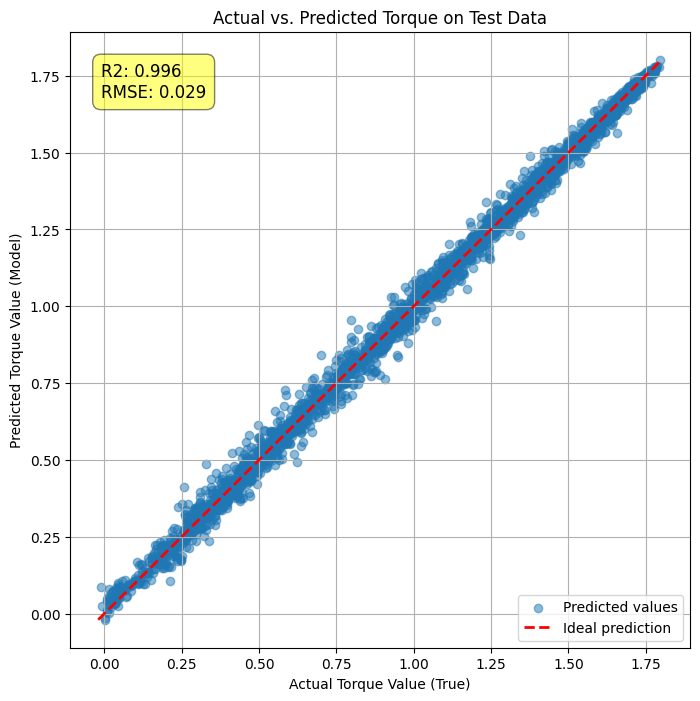

In [37]:
from sklearn.metrics import r2_score  # R2スコア計算のためにインポート

# 訓練済みモデルのファイルパス
MODEL_PATH = "../best_vgg_like_1channel_regressor.keras"  # ★★★ 実際のファイル名に合わせてください ★★★

print(f"\n訓練済みモデル {MODEL_PATH} をロードします...")
try:
    # カスタムモデルをロードする場合、カスタムオブジェクトを渡す必要がないことが多い
    # (モデルアーキテクチャがKerasの標準レイヤーで構成されていれば)
    # もしカスタムオブジェクト（カスタムレイヤーやカスタム損失関数など）があれば、
    # load_model の custom_objects引数で指定する必要があります。
    # 今回の vgg_like_1channel_regressor は標準レイヤーのみなので不要なはず。
    model = tf.keras.models.load_model(MODEL_PATH)
    print("モデルのロードが完了しました。")
    model.summary()  # ロードされたモデルの概要を表示
except Exception as e:
    print(f"エラー: モデルのロードに失敗しました: {e}")
    print(
        "テスト評価を実行する前に、モデルが正しくロードされていることを確認してください。"
    )
    # エラーが発生した場合、以降の処理が失敗する可能性があるため、ここで終了するか、
    # ダミーの model オブジェクトがある場合はそのまま進む（ただし評価結果は無意味になる）
    # exit() # 必要に応じてプログラムを終了

# モデルがロードされた後、必要であればコンパイルします。
# .keras 形式で保存した場合、通常オプティマイザの状態も保存されるため、
# 再コンパイルは必須ではありませんが、学習率などを変更したい場合は行います。
# ここでは、評価のみなので、学習時のコンパイル設定が引き継がれることを期待します。
# もし load_model で警告が出る場合や、オプティマイザの状態が復元されない場合は、
# 以下のように再コンパイルが必要になることがあります。
# model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE), # または評価時の学習率
#               loss='mean_squared_error',
#               metrics=['mean_absolute_error', tf.keras.metrics.RootMeanSquaredError()])


# セル 15: テストセットでのモデル評価
print("\n--- テストセットでの評価 ---")

if (
    "model" in locals()
    and model is not None
    and "test_dataset" in locals()
    and test_dataset is not None
):
    try:
        test_loss, test_mae, test_rmse_metric_value = model.evaluate(
            test_dataset, verbose=1
        )
        print(f"テストデータの損失 (MSE): {test_loss:.4f}")
        print(f"テストデータの平均絶対誤差 (MAE): {test_mae:.4f}")
        print(f"テストデータのRMSE (Keras Metric): {test_rmse_metric_value:.4f}")

        # 全テストデータに対する予測を一度に行う
        all_test_predictions = []
        all_test_true_values = []

        print("テストデータから真の値と予測値を取得しています...")
        for images, labels in test_dataset:  # バッチ処理されているためループで集める
            predictions_batch = model.predict_on_batch(images)
            all_test_predictions.extend(predictions_batch.flatten())
            all_test_true_values.extend(labels.numpy().flatten())

        all_test_predictions = np.array(all_test_predictions)
        all_test_true_values = np.array(all_test_true_values)

        # R2スコアの計算
        if (
            len(all_test_true_values) > 0 and len(all_test_predictions) > 0
        ):  # データがあるか確認
            r2 = r2_score(all_test_true_values, all_test_predictions)
            print(f"テストデータのR2スコア: {r2:.4f}")

            # RMSEの再計算 (numpyベースで、Kerasメトリックと一致するか確認)
            manual_rmse = np.sqrt(
                np.mean((all_test_predictions - all_test_true_values) ** 2)
            )
            print(f"テストデータのRMSE (numpy計算): {manual_rmse:.4f}")

            # (オプション) 予測結果の散布図プロット
            import matplotlib.pyplot as plt

            plt.figure(figsize=(8, 8))
            plt.scatter(
                all_test_true_values,
                all_test_predictions,
                alpha=0.5,
                label="Predicted values",
            )
            min_val = min(all_test_true_values.min(), all_test_predictions.min())
            max_val = max(all_test_true_values.max(), all_test_predictions.max())
            plt.plot(
                [min_val, max_val],
                [min_val, max_val],
                "r--",
                lw=2,
                label="Ideal prediction",
            )
            plt.xlabel("Actual Torque Value (True)")
            plt.ylabel("Predicted Torque Value (Model)")
            plt.title("Actual vs. Predicted Torque on Test Data")
            plt.legend()
            plt.grid(True)
            plt.text(
                0.05,
                0.95,
                f"R2: {r2:.3f}\nRMSE: {manual_rmse:.3f}",
                transform=plt.gca().transAxes,
                fontsize=12,
                verticalalignment="top",
                bbox=dict(boxstyle="round,pad=0.5", fc="yellow", alpha=0.5),
            )
            plt.show()

        else:
            print(
                "テストデータまたは予測結果が空のため、R2スコアとRMSE(numpy)の計算をスキップしました。"
            )

    except Exception as e:
        print(f"テスト評価中にエラーが発生しました: {e}")
else:
    print(
        "モデルまたはテストデータセットが正しく準備されていません。評価をスキップします。"
    )


## 訓練データセットから画像データを取得し，予測を行う

In [38]:
# # (必要なインポートや train_dataset が定義されている前提)
# import time  # 時間計測用 (任意)

# import numpy as np
# import tensorflow as tf

# print("\n--- Collecting processed training images into variable X ---")

# # 訓練データセットから前処理済みの画像データを収集するためのリスト
# all_train_images_list = []
# all_train_labels_list = []
# print("Gathering processed images from train_dataset...")
# start_time = time.time()

# # train_dataset をイテレートして画像データを抽出
# # train_dataset が定義されていない場合は、セル7などを再実行して作成してください。
# # (train_dataset がシャッフルされている場合、元の train_paths との順序は保証されません)
# try:
#     num_batches = tf.data.experimental.cardinality(train_dataset).numpy()
#     if (
#         num_batches == tf.data.experimental.UNKNOWN_CARDINALITY
#         or num_batches == tf.data.experimental.INFINITE_CARDINALITY
#     ):
#         print("Warning: Could not determine the exact number of batches.")
#         num_batches = -1
# except:  # tf.data.experimental.cardinality が使えない/失敗する場合
#     print(
#         "Warning: Could not determine the number of batches using tf.data.experimental.cardinality."
#     )
#     num_batches = -1

# processed_samples = 0
# batch_counter = 0
# for (
#     images_batch,
#     images_labels,
# ) in train_dataset:  # ラベル情報は今回は使用しないので _ で受け取る
#     # バッチ内の画像データをNumPy配列に変換してリストに追加
#     all_train_images_list.append(images_batch.numpy())
#     all_train_labels_list.append(images_labels.numpy())
#     processed_samples += images_batch.shape[0]
#     batch_counter += 1
#     if num_batches > 0:
#         print(
#             f"Processing batch {batch_counter}/{num_batches}, Samples processed: {processed_samples}",
#             end="\r",
#         )
#     else:
#         print(
#             f"Processing batch {batch_counter}, Samples processed: {processed_samples}",
#             end="\r",
#         )


# print("\nConcatenating collected image batches...")
# # リストに格納された複数のバッチ（NumPy配列）を一つの大きなNumPy配列に結合
# if all_train_images_list:
#     X_train_images = np.concatenate(all_train_images_list, axis=0)
#     # ユーザーが指定した変数名 'X' に代入
#     X = X_train_images
#     end_time = time.time()
#     print(f"\nFinished collecting images in {end_time - start_time:.2f} seconds.")
#     print(
#         f"Processed training images are now stored in variable 'X' with shape: {X.shape}"
#     )
#     # メモリ使用量の概算を表示 (GiB単位)
#     print(f"Approximate memory usage of X: {X.nbytes / (1024**3):.2f} GiB")

#     # 必要であれば、元のリストを削除してメモリを解放
#     del all_train_images_list

# else:
#     print("\nNo images were collected from train_dataset. Variable 'X' is not created.")
#     X = None  # XをNoneに設定

# # これで変数 X に前処理済みの訓練画像データ (NumPy配列) が格納されました。
# # この後の処理で、この変数 X を使用できますが、メモリ使用量に注意してください。


# # model.predict() を使って予測を実行
# try:
#     # batch_size を指定すると、メモリ使用量を抑えられる
#     # ご自身の環境のメモリに合わせて調整してください (例: 64, 32, 16)
#     # 指定しない場合は、TensorFlowが自動で決定しようとします
#     predict_batch_size = 64  # バッチサイズを調整
#     print(f"Starting prediction with batch_size={predict_batch_size}...")
#     Y_predictions_raw = model.predict(X, batch_size=predict_batch_size, verbose=1)

#     # 予測結果は通常 (サンプル数, 1) の形状なので、(サンプル数,) に平坦化する
#     Y = Y_predictions_raw.flatten()

#     end_time = time.time()
#     print(f"\nFinished prediction in {end_time - start_time:.2f} seconds.")
#     print(f"Predictions are now stored in variable 'Y' with shape: {Y.shape}")

#     # 予測結果の最初のいくつかを表示 (確認用)
#     print(f"First 5 predictions in Y: {Y[:5]}")

# except Exception as e:
#     print(f"\nAn error occurred during prediction: {e}")
#     print("Consider reducing the 'predict_batch_size' if this is a memory issue.")
#     Y = None  # エラーが発生した場合は Y を None に設定

# # これで変数 Y に、入力 X (訓練画像データ) に対する予測値が格納されました。

# X = X.reshape(X.shape[0], X.shape[1] * X.shape[2] * X.shape[3])
# print(X.shape, Y.shape, all_train_labels_list)


In [39]:
# Y_true_train_data = np.concatenate(all_train_labels_list, axis=0)
# print(Y_true_train_data.shape)


## X, Y, 正解値をファイルに書き込む

In [40]:
# import os
# import time

# import numpy as np

# # --- Save X, Y (predictions), and Y_true (actual labels) to a compressed .npz file ---

# # 保存するファイル名を定義 (拡張子は .npz)
# filename = "gray_training_data_preprocessed_predicted_and_true_labels.npz"  # ファイル名を少し変更して内容を反映
# save_directory = "../20250425_data"  # 保存先のディレクトリ
# os.makedirs(save_directory, exist_ok=True)  # 保存先ディレクトリがなければ作成
# full_filepath = os.path.join(save_directory, filename)

# print(f"\n--- Saving data to {full_filepath} ---")

# # ★★★ 元の訓練データの正解ラベルを格納している変数名を指定 ★★★
# # 例: Y_true_train, train_targets, all_targets_train など、ご自身のコードに合わせてください。
# # ここでは 'Y_true_train_data' という名前の変数に正解ラベルが入っていると仮定します。
# # この変数は、X や Y と同じサンプル数・同じ順序である必要があります。


# if "Y_true_train_data" not in locals() or Y_true_train_data is None:
#     print(
#         "Warning: 'X' not found. Cannot create dummy Y_true_train_data of appropriate size."
#     )
#     Y_true_train_data = None


# # 変数 X (画像データ), Y (予測値), Y_true_train_data (正解ラベル) が存在するか確認
# if (
#     "X" in locals()
#     and "Y" in locals()
#     and "Y_true_train_data" in locals()
#     and X is not None
#     and Y is not None
#     and Y_true_train_data is not None
# ):
#     # Y と Y_true_train_data の形状が一致するか確認 (Yは予測値なのでXのサンプル数と同じはず)
#     if X.shape[0] != Y.shape[0] or X.shape[0] != Y_true_train_data.shape[0]:
#         print(
#             "Error: Mismatch in the number of samples between X, Y, and Y_true_train_data."
#         )
#         print(
#             f"X shape[0]: {X.shape[0]}, Y shape[0]: {Y.shape[0]}, Y_true_train_data shape[0]: {Y_true_train_data.shape[0]}"
#         )
#     else:
#         start_time = time.time()
#         try:
#             # np.savez_compressed を使用して圧縮形式で保存
#             # キーワード引数で各配列に名前を付ける
#             np.savez_compressed(
#                 full_filepath,
#                 x_data=X,  # 前処理済み画像データ
#                 y_predicted_data=Y,  # モデルによる予測値
#                 y_true_actual_data=Y_true_train_data,  # ★★★ 元の訓練データの正解ラベル ★★★
#             )

#             end_time = time.time()
#             print(f"Successfully saved data to {full_filepath}")
#             print(f"  X shape: {X.shape}")
#             print(f"  Y (predicted) shape: {Y.shape}")
#             print(f"  Y_true (actual) shape: {Y_true_train_data.shape}")
#             print(f"Saving took {end_time - start_time:.2f} seconds.")

#             file_size_mb = os.path.getsize(full_filepath) / (1024**2)
#             print(f"File size: {file_size_mb:.2f} MB")

#         except Exception as e:
#             print(f"An error occurred while saving the file: {e}")
# else:
#     missing_vars = []
#     if "X" not in locals() or X is None:
#         missing_vars.append("'X'")
#     if "Y" not in locals() or Y is None:
#         missing_vars.append("'Y' (predictions)")
#     if "Y_true_train_data" not in locals() or Y_true_train_data is None:
#         missing_vars.append("'Y_true_train_data' (true labels)")
#     print(
#         f"Error: Variables {', '.join(missing_vars)} not found or are None. Cannot save."
#     )

# # メモリを解放したい場合は、ここで X や Y, Y_true_train_data を削除することも検討
# # del X
# # del Y
# # del Y_true_train_data
# # print("Variables X, Y, and Y_true_train_data deleted from memory.")


## 画像データX, 予測値Y, 正解値の読み込み

In [41]:
import os

import numpy as np

# 保存したファイル名を指定
filename = "gray_training_data_preprocessed_predicted_and_true_labels.npz"
load_directory = "../20250425_data"  # 保存したディレクトリと同じ場所を指定
full_filepath = os.path.join(load_directory, filename)

# 読み込み時のイメージ
loaded_data = np.load(full_filepath)
X_loaded = loaded_data["x_data"]
Y_predicted_loaded = loaded_data["y_predicted_data"]
Y_true_loaded = loaded_data["y_true_actual_data"]


In [42]:
print(X_loaded.shape, Y_predicted_loaded.shape, Y_true_loaded.shape)


(24800, 50176) (24800,) (24800,)


## AIMEの実装

In [43]:
import sys

from sklearn.preprocessing import StandardScaler

if "/home/kosukeyano/workspace/IPMSM" not in sys.path:
    sys.path.append("/home/kosukeyano/workspace/IPMSM/")

from aime_xai import AIME


In [44]:
aime = AIME()


In [45]:
# X用とY用で別々のスケーラーを使用
scaler_X = StandardScaler()
X_scaled = scaler_X.fit_transform(X_loaded)

scaler_Y = StandardScaler()
# Y_predicted_loadedは1次元配列なので、2次元にreshapeしてからスケーリング
Y_predicted_scaled = scaler_Y.fit_transform(Y_predicted_loaded.reshape(-1, 1))

print(f"X_scaled shape: {X_scaled.shape}")
print(f"Y_predicted_scaled shape: {Y_predicted_scaled.shape}")


X_scaled shape: (24800, 50176)
Y_predicted_scaled shape: (24800, 1)


In [46]:
aime.create_explainer(X_scaled, Y_predicted_scaled, normalize=False)


In [47]:
aime.A_dagger.shape


(50176, 1)

In [48]:
feature_names = [f"pixel_{i}" for i in range(X_scaled.shape[1])]


In [49]:
import matplotlib.pyplot as plt


## 大局的特徴重要度

グローバル特徴重要度の形状: (1, 50176)
出力次元: ['Torque']


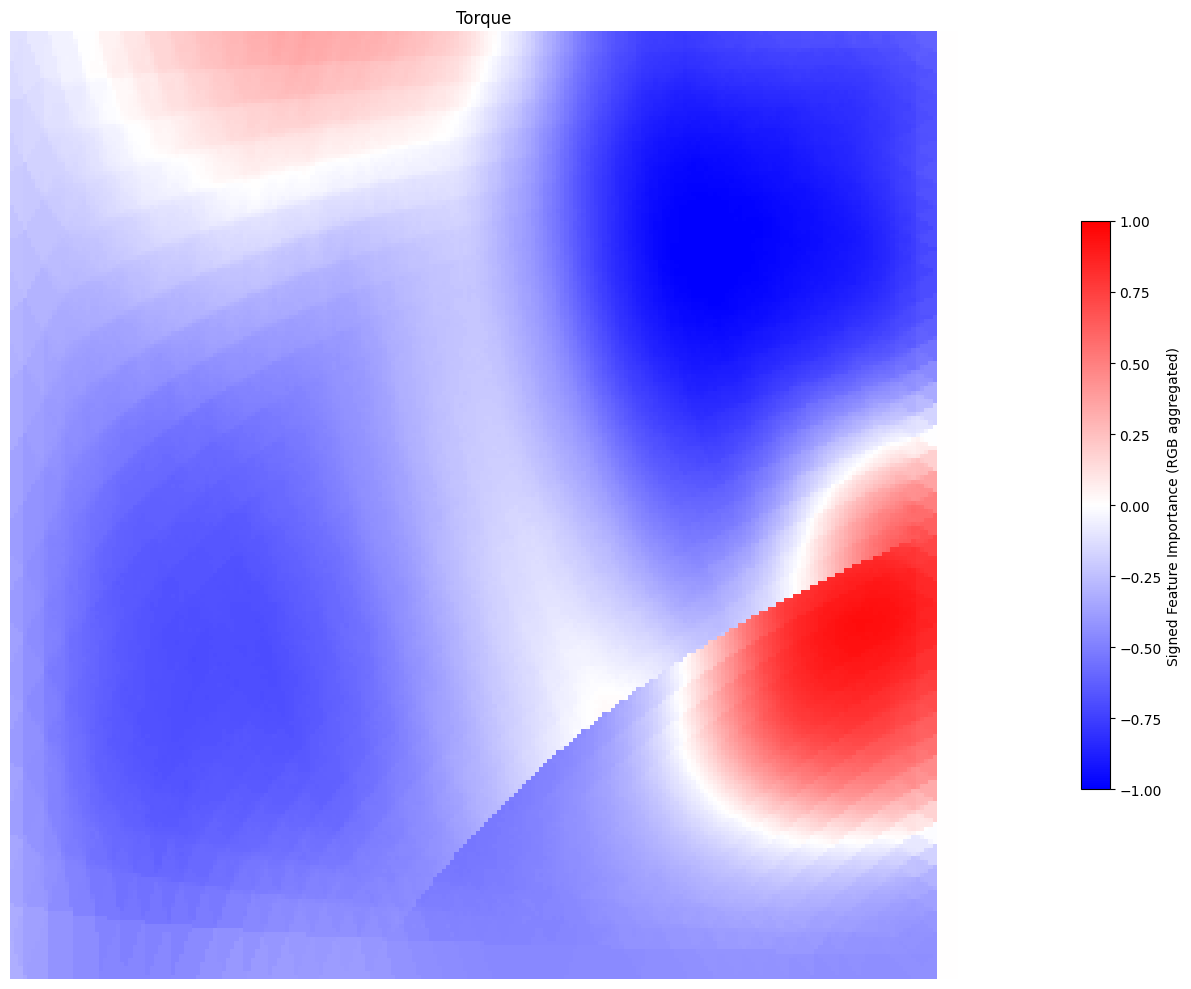

グローバル特徴重要度の可視化が完了しました。
このヒートマップは、モデルがトルク予測のために画像のどの領域を重視しているかを示しています。


In [50]:
# グローバル特徴重要度の計算（可視化なし）
df_global_importance = aime.global_feature_importance_without_viz(
    feature_names=feature_names,
    class_names=["Torque"],  # 回帰問題なので1つの出力
    top_k=None,  # 全ての特徴を使用
    top_k_criterion="average",
)

print(f"グローバル特徴重要度の形状: {df_global_importance.shape}")
print(f"出力次元: {df_global_importance.index.tolist()}")

# show_global_signed_gridを使用して可視化
# グレースケール画像（1チャンネル）で、回帰問題（1つの出力）なので1x1グリッド
aime.show_global_signed_grid(
    df_global=df_global_importance,
    class_names=["Torque"],  # 回帰問題の出力名
    H=IMG_HEIGHT,  # 224
    W=IMG_WIDTH,  # 224
    n_channels=1,  # グレースケール画像
    rows=1,  # 出力が1つなので1行
    cols=1,  # 出力が1つなので1列
    fname=None,  # 保存する場合はファイル名を指定（例: "global_importance.png"）
    mode="maxabs",  # 集約方法: "maxabs" または "l2"
)

print("グローバル特徴重要度の可視化が完了しました。")
print(
    "このヒートマップは、モデルがトルク予測のために画像のどの領域を重視しているかを示しています。"
)


## 大局的特徴重要度 低トルク(<=0.5)・高トルク(>=1.5)ごと

low (<=0.5): 4054 samples, high (>=1.5): 6227 samples


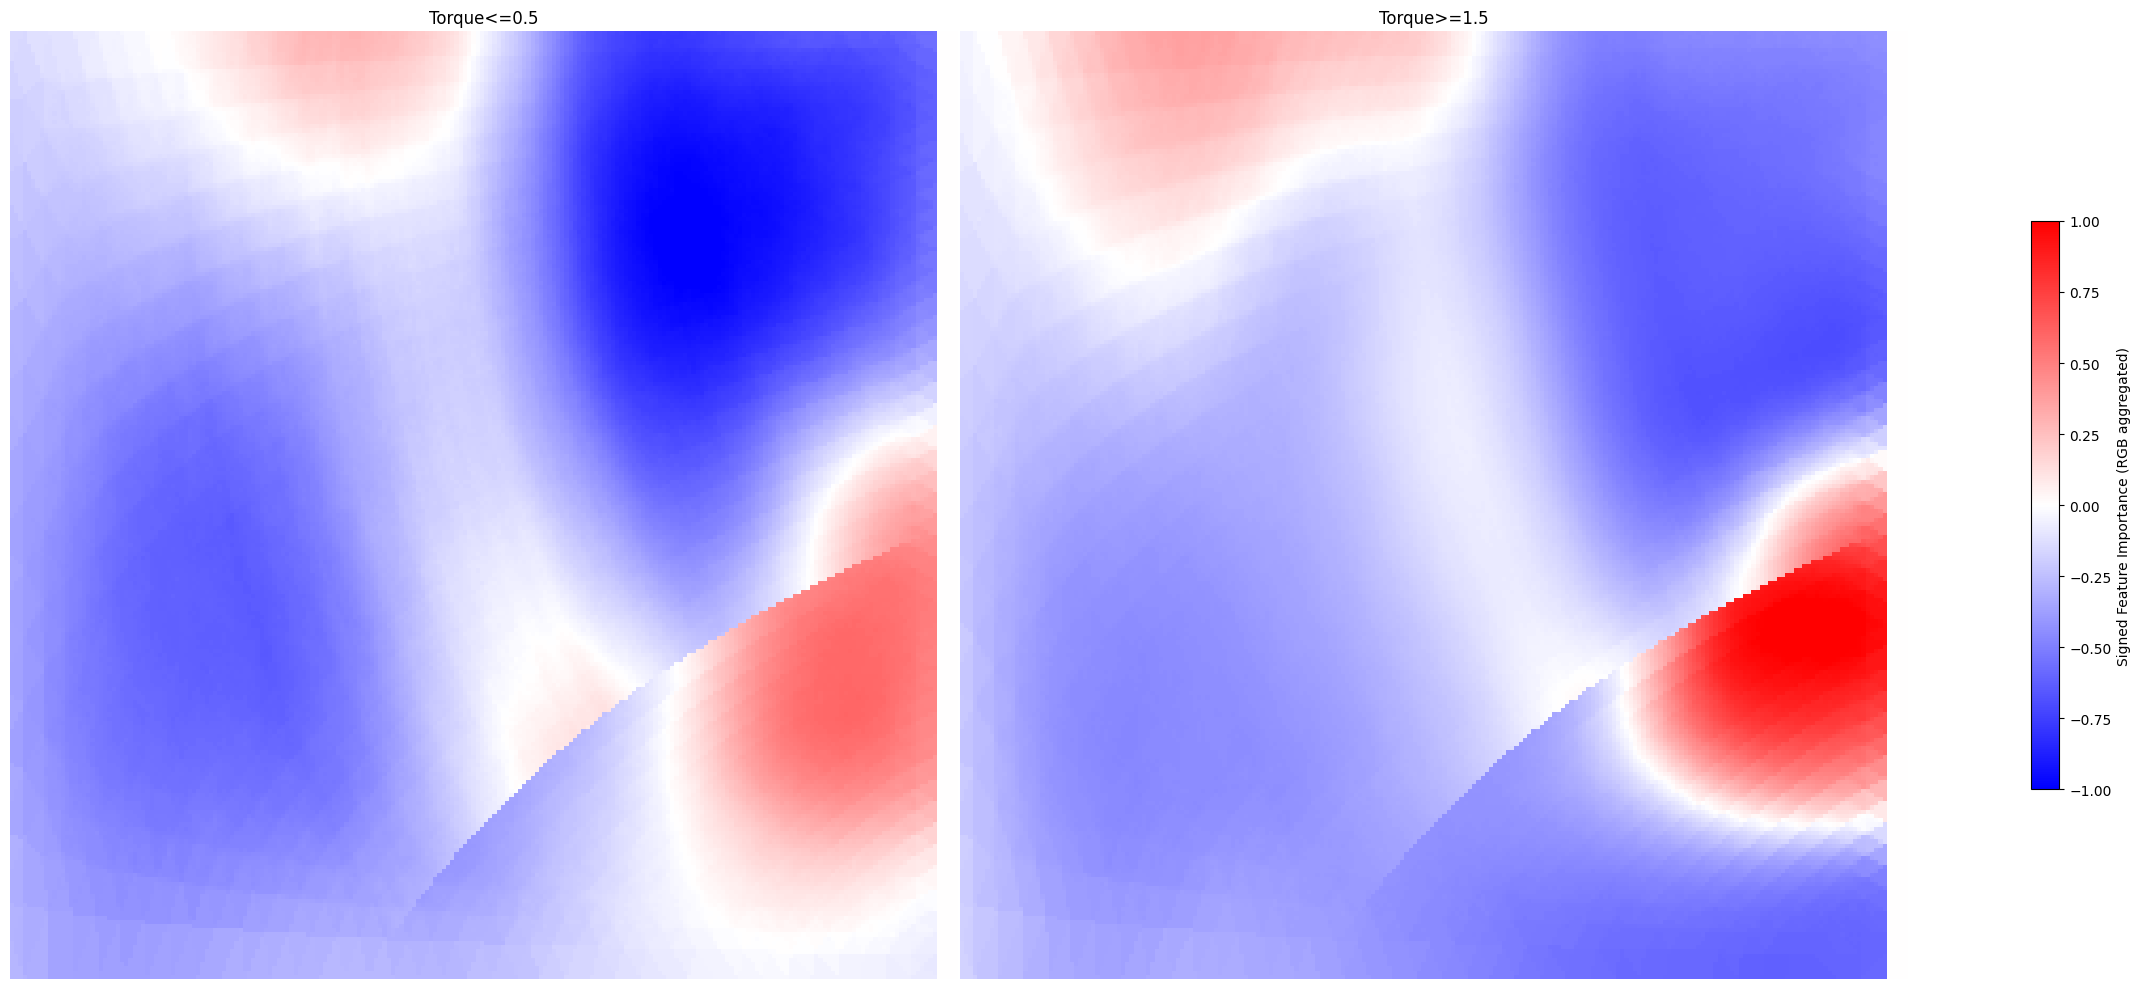

In [51]:
# 低トルク(<=0.5)・高トルク(>=1.5)ごとにグローバル特徴重要度を算出・可視化
# 既存の変数: X_scaled, Y_predicted_scaled, Y_true_loaded, feature_names, IMG_HEIGHT, IMG_WIDTH

# 1) 真値ベースのマスク
y_true = Y_true_loaded.ravel()
mask_low = y_true <= 0.5
mask_high = y_true >= 1.5
print(f"low (<=0.5): {mask_low.sum()} samples, high (>=1.5): {mask_high.sum()} samples")


def compute_global_for(mask, label):
    if mask.sum() == 0:
        return None, None
    X_sub = X_scaled[mask]
    Y_sub = Y_predicted_scaled[mask]  # 既存の設定に合わせて予測値側を使用
    aime_sub = AIME()
    aime_sub.create_explainer(X_sub, Y_sub, normalize=False)
    df = aime_sub.global_feature_importance_without_viz(
        feature_names=feature_names,
        class_names=[label],
        top_k=None,
        top_k_criterion="average",
    )
    return df, aime_sub


df_low, aime_low = compute_global_for(mask_low, "Torque<=0.5")
df_high, aime_high = compute_global_for(mask_high, "Torque>=1.5")

# 2) 2枚並べて可視化（サンプルがある方のみ）
dfs = [d for d in [df_low, df_high] if d is not None]
if len(dfs) == 0:
    print("どちらの条件にも一致するサンプルがありません。")
else:
    df_both = pd.concat(dfs, axis=0)
    class_names_2 = list(df_both.index)
    (aime_low or aime_high).show_global_signed_grid(
        df_global=df_both,
        class_names=class_names_2,
        H=IMG_HEIGHT,
        W=IMG_WIDTH,
        n_channels=1,
        rows=1,
        cols=len(class_names_2),
        fname=None,
        mode="maxabs",
    )


## 局所的特徴重要度

In [52]:
# # matplotlibの出力設定（Jupyter上で画像を表示するため）
# %matplotlib inline

# # 局所的特徴重要度の可視化例
# # 分析したいサンプルのインデックスを指定
# index_to_analyze = 0  # ここで分析したい画像のインデックスを指定

# # 元画像データの取得（前処理済み）
# x_sample_flat = X_loaded[index_to_analyze]  # フラット化された画像データ
# y_predicted = Y_predicted_loaded[index_to_analyze]  # 予測値
# y_true = Y_true_loaded[index_to_analyze]  # 正解値

# # 元画像をリシェイプ（表示用）
# # グレースケール画像なので (H, W) に変換
# x_sample_2d = x_sample_flat.reshape(IMG_HEIGHT, IMG_WIDTH)
# y_pred_scaled = scaler_Y.transform(np.array([[y_predicted]])).ravel()[0]

# # ローカル特徴重要度の計算
# # AIMEのlocal_feature_importance_without_vizを使用
# local_importance_df = aime.local_feature_importance_without_viz(
#     x=X_scaled[index_to_analyze],  # スケール済みデータを使用
#     y=np.array([y_pred_scaled]),  # 予測値（1次元配列として渡す）
#     feature_names=feature_names,
#     scale=False,  # 既にスケール済みなのでFalse
#     scaler=None,
#     ignore_zero_features=True,
# )

# # DataFrameから重要度の値を取得してリシェイプ
# local_importance_flat = local_importance_df.iloc[0].values
# local_importance_2d = local_importance_flat.reshape(IMG_HEIGHT, IMG_WIDTH, 1)

# # show_local_with_originalを使用して可視化
# aime.show_local_with_original(
#     orig_img3=x_sample_2d,
#     contrib_img3=local_importance_2d,  # 局所特徴重要度（2D）
#     true_name=f"True: {y_true:.4f}, Pred: {y_predicted:.4f}",  # ラベル情報
#     fname=None,  # 保存する場合はファイル名を指定
#     mode="maxabs",  # 集約方法: "maxabs" または "l2"
# )

# print(f"サンプル {index_to_analyze} の可視化が完了しました。")
# print(f"正解値: {y_true:.4f}, 予測値: {y_predicted:.4f}")


## 訓練データ全体に対してAIME可視化を保存


In [53]:
# import glob
# import os
# import time

# import matplotlib
# import matplotlib.pyplot as plt
# import numpy as np
# from PIL import Image

# # 画像表示を無効化（保存のみ）
# matplotlib.use("Agg")

# # 保存先ディレクトリを作成
# output_dir = "/home/kosukeyano/workspace/IPMSM/20250425_data/AIME_visualizations"
# os.makedirs(output_dir, exist_ok=True)
# print(f"保存先ディレクトリ: {output_dir}")

# # Material_dディレクトリの全ファイルを取得（ソート済み）
# material_d_dir = "/home/kosukeyano/workspace/IPMSM/20250425_data/Material_d"
# all_material_d_files = sorted(glob.glob(os.path.join(material_d_dir, "SingleI_*.bmp")))
# print(f"Material_dディレクトリの全ファイル数: {len(all_material_d_files)}")

# # 訓練データのパス（ソート済み）を取得
# # train_pathsはセル5で定義されているが、シャッフルされているため、
# # 元のall_image_pathsから訓練データのみを抽出する必要がある
# # ここでは、train_pathsをソートして処理する
# train_paths_sorted = sorted(train_paths)
# print(f"訓練データファイル数: {len(train_paths_sorted)}")

# # 訓練データの各ファイルについて可視化を実行
# print("\n訓練データに対してAIME可視化を実行中...")
# start_time = time.time()

# # 進捗バー設定（tqdmが使えない場合はフォールバックしてprint）
# try:
#     from tqdm.auto import tqdm  # type: ignore

#     use_tqdm = True
#     pbar = tqdm(train_paths_sorted, desc="AIME可視化", unit="img")
# except Exception:
#     use_tqdm = False
#     pbar = train_paths_sorted

# for idx, img_path in enumerate(pbar):
#     if idx % 100 == 0:
#         elapsed = time.time() - start_time

#     # ファイル名を取得（拡張子はBMPのまま出力）
#     basename = os.path.basename(img_path)
#     # 変更前:
#     # basename_png = basename.replace(".bmp", ".png")
#     # output_path = os.path.join(output_dir, basename_png)
#     # 変更後: ヒートマップをBMPで保存（同名 .bmp）
#     basename_bmp = basename
#     output_path = os.path.join(output_dir, basename_bmp)

#     # 画像を読み込み（前処理を再実行）
#     img = load_img(
#         img_path, target_size=(IMG_HEIGHT, IMG_WIDTH), color_mode="grayscale"
#     )
#     img_array = img_to_array(img)  # (height, width, 1)
#     img_array_scaled = img_array / 255.0  # スケーリング

#     # フラット化してスケーリング
#     x_sample_flat = img_array_scaled.flatten()
#     x_sample_scaled = scaler_X.transform(x_sample_flat.reshape(1, -1))[0]

#     # モデルで予測
#     y_pred = model.predict(
#         img_array_scaled.reshape(1, IMG_HEIGHT, IMG_WIDTH, 1), verbose=0
#     )[0, 0]
#     y_pred_scaled = scaler_Y.transform(np.array([[y_pred]])).ravel()[0]

#     # CSVファイルから正解値を取得（保存画像には使用しない）
#     parts_str = basename.replace("SingleI_", "").replace(".bmp", "")
#     parts = parts_str.split("_")
#     csv_filename = f"Data_{parts[0]}_{parts[1]}.csv"
#     csv_filepath = os.path.join(CSV_BASE_PATH, csv_filename)
#     if os.path.exists(csv_filepath):
#         y_true = get_target_value(csv_filepath)
#     else:
#         y_true = np.nan

#     # ローカル特徴重要度の計算
#     local_importance_df = aime.local_feature_importance_without_viz(
#         x=x_sample_scaled,
#         y=np.array([y_pred_scaled]),
#         feature_names=feature_names,
#         scale=False,
#         scaler=None,
#         ignore_zero_features=True,
#     )

#     # 重要度をリシェイプして符号付き2Dに変換
#     local_importance_flat = local_importance_df.iloc[0].values
#     local_importance_2d = local_importance_flat.reshape(IMG_HEIGHT, IMG_WIDTH, 1)
#     signed2d = aime.compute_signed_2d(local_importance_2d, mode="maxabs")

#     # 変更前: 元画像とヒートマップ（PNG, タイトル/カラーバーあり）
#     # aime.show_local_with_original(
#     #     orig_img3=img_array_scaled.squeeze(),
#     #     contrib_img3=local_importance_2d,
#     #     true_name=f"True: {y_true:.4f}, Pred: {y_predicted_scaled:.4f}",
#     #     fname=output_path,
#     #     mode="maxabs",
#     # )

#     # 変更後: ヒートマップのみをBMPで保存（バー・文字なし）
#     # MatplotlibはBMP保存に非対応のため、PILで保存
#     # カラーマップ適用（inferno, 値域[-1,1]を0-255に線形マップ）
#     cmap = matplotlib.colormaps.get_cmap("inferno")  # 旧: cm.get_cmap("inferno")
#     signed_norm = (np.clip(signed2d, -1, 1) + 1.0) / 2.0  # [-1,1] -> [0,1]
#     colored = (cmap(signed_norm)[:, :, :3] * 255).astype(np.uint8)  # RGB
#     img_pil = Image.fromarray(colored)
#     img_pil.save(output_path, format="BMP")

#     # メモリを解放
#     plt.close("all")

# end_time = time.time()
# (print("\n完了！"),)
# print(f"総処理時間: {end_time - start_time:.1f}秒")
# print(f"保存先: {output_dir}")
# print(f"保存ファイル数: {len(train_paths_sorted)}")


## 元画像，AIMEの出力， ヒストグラム， 真値，予測値

2026-03-09 14:28:31.685852: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


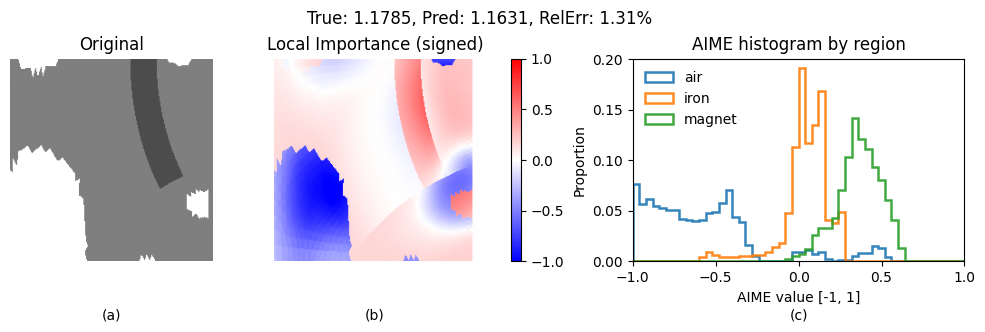

サンプル 1 の可視化とPDF保存が完了しました: /home/kosukeyano/workspace/IPMSM/outputs/AIME_PDF/torque_1.178506.pdf
ランダム100枚のPDFを /home/kosukeyano/workspace/IPMSM/outputs/AIME_PDF に保存します。


2026-03-09 14:28:36.885327: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}
2026-03-09 14:28:42.141711: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),

ランダム保存が完了しました。


In [54]:
# matplotlibの出力設定（Jupyter上で画像を表示するため）
%matplotlib inline
import os

from PIL import Image

# 出力先ディレクトリ（PDF保存）
output_dir_pdf = "/home/kosukeyano/workspace/IPMSM/outputs/AIME_PDF"
os.makedirs(output_dir_pdf, exist_ok=True)

# ファイル名用に train_paths_sorted を準備
try:
    train_paths_sorted = sorted(train_paths)
except Exception:
    train_paths_sorted = []

# 領域マスク関連の設定
mask_dir = "/home/kosukeyano/workspace/IPMSM/20250425_data/Material_d"
region_colors = {"air": "tab:blue", "iron": "tab:orange", "magnet": "tab:green"}
mask_path_override = None  # 例: "/home/.../Material_d_Gray/SingleI_0_0.bmp"


def build_region_masks_from_label(label_img_uint8: np.ndarray) -> dict:
    vals, counts = np.unique(label_img_uint8, return_counts=True)

    # 離散レベルが少ない（例: 3値マスク）場合は等値判定で十分
    if len(vals) <= 6:
        top3_idx = np.argsort(counts)[-3:]
        top3_vals = vals[top3_idx]
        ordered = np.sort(top3_vals)  # 明度順（暗→明）
        v_dark, v_mid, v_bright = ordered[0], ordered[1], ordered[2]
        return {
            "magnet": label_img_uint8 == v_dark,
            "iron": label_img_uint8 == v_mid,
            "air": label_img_uint8 == v_bright,
        }

    # 連続トーンの場合は 1D KMeans(3クラス) で分割
    img_flat = label_img_uint8.reshape(-1).astype(np.float32)

    # 初期中心は分位数から与える
    centers = np.array(
        [
            np.percentile(img_flat, 16),
            np.percentile(img_flat, 50),
            np.percentile(img_flat, 84),
        ],
        dtype=np.float32,
    )

    for _ in range(25):
        d = np.abs(img_flat[:, None] - centers[None, :])
        labels = d.argmin(axis=1)
        new_centers = np.array(
            [
                img_flat[labels == k].mean() if np.any(labels == k) else centers[k]
                for k in range(3)
            ],
            dtype=np.float32,
        )
        if np.max(np.abs(new_centers - centers)) < 1e-3:
            centers = new_centers
            break
        centers = new_centers

    # 空クラスタ等の異常時は分位数しきい値にフォールバック
    if any(not np.any(labels == k) for k in range(3)):
        q1 = np.percentile(img_flat, 33)
        q2 = np.percentile(img_flat, 66)
        return {
            "magnet": label_img_uint8 <= q1,
            "iron": (label_img_uint8 > q1) & (label_img_uint8 <= q2),
            "air": label_img_uint8 > q2,
        }

    # 明度（中心値）の昇順で material を割り当て
    order = np.argsort(centers)  # 0:暗, 1:中間, 2:明
    labels_2d = labels.reshape(label_img_uint8.shape)
    masks = {
        "magnet": labels_2d == order[0],
        "iron": labels_2d == order[1],
        "air": labels_2d == order[2],
    }
    return masks


def build_region_masks_from_color_label(
    label_img_rgb: np.ndarray, tolerance: int = 40
) -> dict:
    """
    RGBラベル画像から領域マスクを生成する。
    色の対応: 赤(255,0,0)=magnets, 灰=iron, 白(255,255,255)=air。
    tolerance は各チャネルの最大差の許容値。
    """
    if label_img_rgb.ndim != 3:
        raise ValueError(
            "label_img_rgb must be an RGB image with shape (H, W, 3) or (H, W, 4)."
        )
    # RGBA の場合はアルファを捨てる
    if label_img_rgb.shape[2] == 4:
        label_img_rgb = label_img_rgb[:, :, :3]

    img_i16 = label_img_rgb.astype(np.int16)

    def near(color_rgb):
        target = np.array(color_rgb, dtype=np.int16)
        diff = np.abs(img_i16 - target[None, None, :])
        return np.max(diff, axis=2) <= tolerance

    mask_red = near([255, 0, 0])
    mask_white = near([255, 255, 255])
    # 灰=その他（赤・白以外）として扱う（微妙な色揺れにも頑健）
    mask_iron = (~mask_red) & (~mask_white)

    return {"magnet": mask_red, "iron": mask_iron, "air": mask_white}


def render_aime_figure(index_to_analyze: int):
    # --- 入力画像はマスク参照と同じベース名のファイルを使用する ---
    img_path = None
    if (
        "train_paths_sorted" in globals()
        and train_paths_sorted
        and index_to_analyze < len(train_paths_sorted)
    ):
        img_path = train_paths_sorted[index_to_analyze]
    elif mask_path_override and os.path.exists(mask_path_override):
        # マスクのベース名から Gray 画像パス候補を作成
        basename_guess = os.path.basename(mask_path_override)
        candidate_img = os.path.join(IMG_BASE_PATH, basename_guess)
        if os.path.exists(candidate_img):
            img_path = candidate_img

    # 画像読み込みと前処理
    x_sample_2d = None
    x_scaled_for_aime = None
    y_predicted = None
    y_true = None

    if img_path and os.path.exists(img_path):
        img = load_img(
            img_path, target_size=(IMG_HEIGHT, IMG_WIDTH), color_mode="grayscale"
        )
        img_array = img_to_array(img)  # (H, W, 1)
        img_array_scaled = img_array / 255.0
        x_sample_2d = img_array_scaled.squeeze(axis=-1)
        x_sample_flat = x_sample_2d.reshape(-1)
        # AIMEの学習時スケーラでスケール
        x_scaled_for_aime = scaler_X.transform(x_sample_flat.reshape(1, -1))[0]

        # 予測値（可能ならモデルから計算）
        try:
            y_predicted = float(
                model.predict(
                    img_array_scaled.reshape(1, IMG_HEIGHT, IMG_WIDTH, 1), verbose=0
                )[0, 0]
            )
        except Exception:
            # OLD: 事前保存の配列に依存（不一致の可能性があるため非推奨）
            # y_predicted = Y_predicted_loaded[index_to_analyze]
            y_predicted = float("nan")

        # 真値はCSVから取得
        try:
            parts_str = (
                os.path.basename(img_path).replace("SingleI_", "").replace(".bmp", "")
            )
            parts = parts_str.split("_")
            if len(parts) >= 2:
                csv_filename = f"Data_{parts[0]}_{parts[1]}.csv"
                csv_filepath = os.path.join(CSV_BASE_PATH, csv_filename)
                y_true = (
                    get_target_value(csv_filepath)
                    if os.path.exists(csv_filepath)
                    else np.nan
                )
            else:
                y_true = np.nan
        except Exception:
            y_true = np.nan

    else:
        # フォールバック: 旧実装（インデックスで X/Y を参照）
        # x_sample_flat = X_loaded[index_to_analyze]
        # y_predicted = Y_predicted_loaded[index_to_analyze]
        # y_true = Y_true_loaded[index_to_analyze]
        x_sample_flat = X_loaded[index_to_analyze]
        y_predicted = float(Y_predicted_loaded[index_to_analyze])
        y_true = float(Y_true_loaded[index_to_analyze])
        x_sample_2d = x_sample_flat.reshape(IMG_HEIGHT, IMG_WIDTH)
        x_scaled_for_aime = X_scaled[index_to_analyze]

    # 相対誤差（真値基準）。ゼロ割防止に微小値を加算
    eps = 1e-12
    rel_err = (
        abs(y_predicted - y_true) / (abs(y_true) + eps)
        if np.isfinite(y_true) and np.isfinite(y_predicted)
        else np.nan
    )

    # ローカル特徴重要度の計算（AIME）
    y_pred_scaled = (
        scaler_Y.transform(np.array([[y_predicted]])).ravel()[0]
        if np.isfinite(y_predicted)
        else 0.0
    )
    local_importance_df = aime.local_feature_importance_without_viz(
        x=x_scaled_for_aime,
        y=np.array([y_pred_scaled]),
        feature_names=feature_names,
        scale=False,
        scaler=None,
        ignore_zero_features=True,
    )

    # DataFrameから重要度の値を取得してリシェイプ
    local_importance_flat = local_importance_df.iloc[0].values
    local_importance_2d = local_importance_flat.reshape(IMG_HEIGHT, IMG_WIDTH, 1)

    # 符号付き2D（[-1,1]）へ変換（ヒストグラム用）
    signed2d = aime.compute_signed_2d(local_importance_2d, mode="maxabs")

    # マスク構築（indexに対応する推定パス）
    mask_path = None
    if mask_path_override and os.path.exists(mask_path_override):
        mask_path = mask_path_override
    elif train_paths_sorted and index_to_analyze < len(train_paths_sorted):
        basename_guess = os.path.basename(train_paths_sorted[index_to_analyze])
        candidate = os.path.join(mask_dir, basename_guess)
        if os.path.exists(candidate):
            mask_path = candidate

    if mask_path and os.path.exists(mask_path):
        # 新: RGBラベル対応。赤=磁石, 灰=鉄, 白=空気
        mask_img = Image.open(mask_path).convert("RGB")
        mask_img = mask_img.resize((IMG_WIDTH, IMG_HEIGHT), resample=Image.NEAREST)
        mask_rgb = np.array(mask_img)

        # 完全なグレースケールなら従来法へフォールバック
        if np.array_equal(mask_rgb[..., 0], mask_rgb[..., 1]) and np.array_equal(
            mask_rgb[..., 1], mask_rgb[..., 2]
        ):
            mask_u8 = mask_rgb[..., 0]
            masks = build_region_masks_from_label(mask_u8)
        else:
            masks = build_region_masks_from_color_label(mask_rgb)
    else:
        # マスク不明時は x_sample_2d の分位数で3分割（近似）
        q1 = np.percentile(x_sample_2d, 33)
        q2 = np.percentile(x_sample_2d, 66)
        masks = {
            "magnet": x_sample_2d <= q1,
            "iron": (x_sample_2d > q1) & (x_sample_2d <= q2),
            "air": x_sample_2d > q2,
        }

    signed2d = np.squeeze(signed2d)
    signed2d = np.clip(signed2d, -1.0, 1.0)

    # 元画像 + AIMEヒートマップ + カラーバー + 領域別AIMEヒストグラム（同一図）
    bins_aime = np.linspace(-1.0, 1.0, 51)
    fig, axes = plt.subplots(
        1,
        4,
        figsize=(10, 3.2),
        constrained_layout=True,
        gridspec_kw={"width_ratios": [1, 1, 0.04, 1.3]},
    )
    ax0, ax1, cax, ax2 = axes

    # 元画像
    ax0.imshow(x_sample_2d, cmap="gray", vmin=0, vmax=1)
    ax0.set_title("Original")
    ax0.axis("off")

    # AIMEヒートマップ
    im = ax1.imshow(signed2d, cmap="bwr", vmin=-1, vmax=1)
    ax1.set_title("Local Importance (signed)")
    ax1.axis("off")
    fig.colorbar(im, cax=cax)

    # 領域別AIMEヒストグラム（重ね描き）
    normalize = True  # True にすると面積差の影響を除去
    for region_name in ["air", "iron", "magnet"]:
        a_vals = signed2d[masks[region_name]].ravel()
        if normalize:
            weights = np.ones_like(a_vals) / max(a_vals.size, 1)
            ax2.hist(
                a_vals,
                bins=bins_aime,
                weights=weights,
                histtype="step",
                linewidth=1.8,
                color=region_colors[region_name],
                label=region_name,
                alpha=0.9,
            )
        else:
            ax2.hist(
                a_vals,
                bins=bins_aime,
                histtype="step",
                linewidth=1.8,
                color=region_colors[region_name],
                label=region_name,
                alpha=0.9,
            )
    ax2.set_title("AIME histogram by region")
    ax2.set_xlabel("AIME value [-1, 1]")
    ax2.set_ylabel("Proportion" if normalize else "Count")
    ax2.legend(frameon=False)
    ax2.set_xlim(-1, 1)
    ax2.set_ylim(bottom=0)
    ax2.margins(x=0)

    # 論文用の小見出しラベルを各サブプロットの下に配置
    for current_ax, label in zip([ax0, ax1, ax2], ["(a)", "(b)", "(c)"]):
        current_ax.text(
            0.5,
            -0.23,
            label,
            transform=current_ax.transAxes,
            ha="center",
            va="top",
            fontsize=10,
            clip_on=False,
        )

    fig.suptitle(
        f"True: {y_true:.4f}, Pred: {y_predicted:.4f}, RelErr: {rel_err * 100:.2f}%"
    )

    return fig, y_true, y_predicted, rel_err


def save_pdf_for_index(index_to_analyze: int, show: bool = False) -> str:
    fig, y_true, y_predicted, rel_err = render_aime_figure(index_to_analyze)

    # 新: トルクの真値をファイル名に使用（例: 1.234500.pdf）
    torque_str = f"{y_true:.6f}"
    pdf_name = f"torque_{torque_str}.pdf"

    # 旧: train_paths_sorted に合わせたファイル名（比較用に残置）
    # if train_paths_sorted and index_to_analyze < len(train_paths_sorted):
    #     base = os.path.basename(train_paths_sorted[index_to_analyze])
    #     stem, _ = os.path.splitext(base)
    #     pdf_name = f"{stem}.pdf"
    # else:
    #     pdf_name = f"index_{index_to_analyze}.pdf"

    pdf_path = os.path.join(output_dir_pdf, pdf_name)
    fig.savefig(pdf_path, format="pdf", bbox_inches="tight")

    if show:
        plt.show()
    plt.close(fig)

    return pdf_path


# 単体可視化 + PDF保存
index_to_analyze = 1
single_pdf = save_pdf_for_index(index_to_analyze, show=True)
print(f"サンプル {index_to_analyze} の可視化とPDF保存が完了しました: {single_pdf}")

# ランダム100枚をPDF保存
num_random_to_save = 100
N_total = len(X_loaded) if "X_loaded" in locals() else 0
if N_total > 0:
    rng = np.random.default_rng(42)
    k = min(num_random_to_save, N_total)
    sample_indices = rng.choice(N_total, size=k, replace=False)
    print(f"ランダム{len(sample_indices)}枚のPDFを {output_dir_pdf} に保存します。")
    for idx in sample_indices:
        save_pdf_for_index(int(idx), show=False)
    print("ランダム保存が完了しました。")
else:
    print("X_loaded が見つからないため、ランダム保存をスキップしました。")


In [55]:
# # --- 可視チェック: ヒートマップに領域境界をオーバレイ ---


# def _overlay_region_boundaries(
#     ax, masks: dict, linewidth: float = 1.6, linestyle: str = "-"
# ) -> None:
#     """各領域マスクの外周を輪郭線で重ね描きする。"""
#     for name in ["air", "iron", "magnet"]:
#         if name not in masks:
#             continue
#         m = masks[name].astype(np.uint8)
#         try:
#             ax.contour(
#                 m,
#                 levels=[0.5],
#                 colors=region_colors[name],
#                 linewidths=linewidth,
#                 linestyles=linestyle,
#             )
#         except Exception:
#             pass


# def show_aime_with_region_overlay(
#     index_to_analyze: int, linewidth: float = 1.6
# ) -> None:
#     """
#     ヒートマップ（signed AIME）上に air/iron/magnet の境界を重ねて表示。
#     """
#     # 入力画像はマスクと同じベース名のファイルを使用
#     img_path = None
#     if (
#         "train_paths_sorted" in globals()
#         and train_paths_sorted
#         and index_to_analyze < len(train_paths_sorted)
#     ):
#         img_path = train_paths_sorted[index_to_analyze]
#     elif mask_path_override and os.path.exists(mask_path_override):
#         basename_guess = os.path.basename(mask_path_override)
#         candidate_img = os.path.join(IMG_BASE_PATH, basename_guess)
#         if os.path.exists(candidate_img):
#             img_path = candidate_img

#     if img_path and os.path.exists(img_path):
#         img = load_img(
#             img_path, target_size=(IMG_HEIGHT, IMG_WIDTH), color_mode="grayscale"
#         )
#         img_array = img_to_array(img)
#         img_array_scaled = img_array / 255.0
#         x_sample_2d = img_array_scaled.squeeze(axis=-1)
#         x_flat = x_sample_2d.reshape(-1)
#         x_for_aime = scaler_X.transform(x_flat.reshape(1, -1))[0]
#         try:
#             y_pred = float(
#                 model.predict(
#                     img_array_scaled.reshape(1, IMG_HEIGHT, IMG_WIDTH, 1), verbose=0
#                 )[0, 0]
#             )
#         except Exception:
#             y_pred = float("nan")
#     else:
#         # フォールバック: 旧実装
#         x_flat = X_loaded[index_to_analyze]
#         x_sample_2d = x_flat.reshape(IMG_HEIGHT, IMG_WIDTH)
#         x_for_aime = X_scaled[index_to_analyze]
#         y_pred = float(Y_predicted_loaded[index_to_analyze])

#     y_pred_scaled = (
#         scaler_Y.transform(np.array([[y_pred]])).ravel()[0]
#         if np.isfinite(y_pred)
#         else 0.0
#     )

#     local_importance_df = aime.local_feature_importance_without_viz(
#         x=x_for_aime,
#         y=np.array([y_pred_scaled]),
#         feature_names=feature_names,
#         scale=False,
#         scaler=None,
#         ignore_zero_features=True,
#     )
#     signed2d = aime.compute_signed_2d(
#         local_importance_df.iloc[0].values.reshape(IMG_HEIGHT, IMG_WIDTH, 1),
#         mode="maxabs",
#     )
#     signed2d = np.clip(np.squeeze(signed2d), -1.0, 1.0)

#     # マスク推定
#     mask_path = None
#     if mask_path_override and os.path.exists(mask_path_override):
#         mask_path = mask_path_override
#     elif train_paths_sorted and index_to_analyze < len(train_paths_sorted):
#         basename_guess = os.path.basename(train_paths_sorted[index_to_analyze])
#         candidate = os.path.join(mask_dir, basename_guess)
#         if os.path.exists(candidate):
#             mask_path = candidate

#     if mask_path and os.path.exists(mask_path):
#         mask_img = Image.open(mask_path).convert("RGB")
#         mask_img = mask_img.resize((IMG_WIDTH, IMG_HEIGHT), resample=Image.NEAREST)
#         mask_rgb = np.array(mask_img)
#         if np.array_equal(mask_rgb[..., 0], mask_rgb[..., 1]) and np.array_equal(
#             mask_rgb[..., 1], mask_rgb[..., 2]
#         ):
#             masks = build_region_masks_from_label(mask_rgb[..., 0])
#         else:
#             masks = build_region_masks_from_color_label(mask_rgb, tolerance=40)
#     else:
#         q1 = np.percentile(x_sample_2d, 33)
#         q2 = np.percentile(x_sample_2d, 66)
#         masks = {
#             "magnet": x_sample_2d <= q1,
#             "iron": (x_sample_2d > q1) & (x_sample_2d <= q2),
#             "air": x_sample_2d > q2,
#         }

#     # 表示: 元画像 + ヒートマップ(境界オーバレイ) + カラーバー
#     fig, axes = plt.subplots(
#         1,
#         3,
#         figsize=(8.6, 3.2),
#         constrained_layout=True,
#         gridspec_kw={"width_ratios": [1, 1, 0.05]},
#     )
#     ax0, ax1, cax = axes

#     ax0.imshow(x_sample_2d, cmap="gray", vmin=0, vmax=1)
#     ax0.set_title("Original")
#     ax0.axis("off")

#     im = ax1.imshow(signed2d, cmap="bwr", vmin=-1, vmax=1)
#     _overlay_region_boundaries(ax1, masks, linewidth=linewidth)
#     ax1.set_title("Local Importance + boundaries")
#     ax1.axis("off")

#     fig.colorbar(im, cax=cax)

#     # 小見出し
#     for current_ax, label in zip([ax0, ax1], ["(a)", "(b)"]):
#         current_ax.text(
#             0.5,
#             -0.23,
#             label,
#             transform=current_ax.transAxes,
#             ha="center",
#             va="top",
#             fontsize=10,
#             clip_on=False,
#         )
#     plt.show()


# # 実行例
# show_aime_with_region_overlay(index_to_analyze=index_to_analyze, linewidth=1.8)
